**Running on Colab?** Just run the setup cell below. It clones the repo and installs the package. For a free GPU: Runtime → Change runtime type → GPU.

In [ ]:
# --- Colab setup (auto-injected by build_notebooks.py; do not edit the .ipynb) ---
import os, sys, subprocess

if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != "tutorials":
    # Clone the repo (this also brings calibration.py and the data/ reference
    # files the notebooks load) and install the package.
    if not os.path.isdir("SRL"):
        url = "https://github.com/StructuralRL/SRL.git"
        subprocess.run(["git", "clone", "--depth=1", url, "SRL"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", "SRL"], check=True)
    # --no-deps: Colab already ships jax (with its matched GPU plugin), optax,
    # numpy, scipy, matplotlib, and tqdm. Installing our pinned jax here would
    # desync it from the preinstalled GPU plugin and crash GPU runtimes.
    # Import srl straight from the clone. A mid-session `pip install -e`
    # registers the package only through a .pth file that Python reads at
    # startup, so it does not take effect in the already-running Colab
    # kernel. Putting the repo root on sys.path makes `import srl` work now.
    sys.path.insert(0, os.path.abspath("SRL"))
    os.chdir("SRL/tutorials_new")
    sys.path.insert(0, os.getcwd())

# 2. The same problem, by the Structural Policy Gradient

This is the notebook that matters most. We solve the **same** fixed-price
household problem a third time, but not by iterating a Bellman operator.
Instead we **maximize lifetime utility directly**: parameterize the consumption
policy, write expected lifetime utility as a function of those parameters, and
**climb it with gradients**. This is the **Structural Policy Gradient (SPG)**,
the algorithm at the core of Structural Reinforcement Learning (SRL), the method
this package implements (Yang, Wang, Schaab & Moll, 2025).

Notebook 1 changed the *tooling* (NumPy → JAX) and held the method fixed; this
notebook does the opposite: **same tooling, new method** (VFI → SPG). As
before, it checks the result against notebook 0's answer.

Two ideas from the paper carry the notebook:

- **Reinforcement learning's core idea:** a value function is an *expectation*,
  and an expectation can be *estimated by simulation*, with no Bellman equation
  needed (paper §3.1).
- **What makes it "Structural":** we do not treat the world as a black box. The
  dynamics we *know* (each household's budget constraint and income process)
  we encode in a transition matrix and differentiate through *exactly*. Only the
  parts we *don't* know (in general equilibrium, the price process) are left to
  simulation. That hybrid is the "S" in SRL.

**Honest up front:** on *this* problem SPG is overkill; VFI already nails it,
faster. We use it here because we can check it against a known answer.
Its payoff is notebook 5, where prices carry aggregate risk and the methods you
know hit the curse of dimensionality.

## What you should already know

- **Notebook 0**: the household problem and its VFI solution (our reference).
- **Notebook 1**: JAX, and especially `grad`: that a transformation turns a
  function into its derivative function. The policy gradient is `grad` aimed at
  lifetime utility.

**No reinforcement-learning background is assumed.**

In [2]:
import inspect
import os

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from calibration import SIGMA, BETA, Q_FIXED   # the one shared calibration (see calibration.py)

jax.config.update("jax_enable_x64", True)   # match notebook 0/1 to high precision

sigma, beta, q = SIGMA, BETA, Q_FIXED       # beta is the discount factor; SPG calls it gamma

# Load notebook 0's grids and reference solution (policy + value) for the overlay.
_here = os.path.dirname(__file__) if "__file__" in globals() else "."
ref = np.load(os.path.join(_here, "data", "nb0_reference.npz"))
b_grid = jnp.asarray(ref["b_grid"])
e_grid = jnp.asarray(ref["e_grid"])
Pi = jnp.asarray(ref["Pi"])
c_policy_np = ref["c_policy"]              # nb-0 consumption policy (n_b, n_y)
V_np = ref["V"]                           # nb-0 value function (n_b, n_y)
n_b, n_y = b_grid.shape[0], e_grid.shape[0]
eps = 1e-9

print(f"n_b={n_b}, n_y={n_y};  sigma={sigma}, beta={beta}, q={q}")

n_b=100, n_y=3;  sigma=2.0, beta=0.98, q=0.995


## Notation, and the plan

We adopt the paper's notation. The individual state is $s=(b,y)$, wealth and
income, on a grid $s\in\{s_1,\dots,s_J\}$ with $J=n_b\,n_y$ points. The
consumption policy $\pi$ maps each state to a choice; on the grid it is a
$J$-vector $\boldsymbol\pi$ with parameters $\boldsymbol\theta$. The price is
$p=q$ (fixed here; it starts moving in notebook 3) and there is no aggregate
shock $z$ yet.

Three bridges take us from VFI to SPG, each from something you did in nb 0:

1. **A value is a simulated expectation:** estimate lifetime utility by
   simulating, not by solving a Bellman equation.
2. **Structural knowledge makes it exactly differentiable:** the *known*
   individual dynamics go into a transition matrix $\mathbf{A}_\pi$ (the *same*
   histogram transition you built in nb 0), so the value is a smooth function of
   $\boldsymbol\theta$ and `grad` differentiates through it exactly.
3. **Climb it:** gradient ascent, $\boldsymbol\theta \leftarrow
   \boldsymbol\theta + \eta\,\nabla_{\boldsymbol\theta}\mathcal{L}$.

We take them in order.

## Bridge 1: a value is a simulated expectation

This is the one idea at the heart of all reinforcement learning. In notebook 0,
$V(s)$ was the fixed point of the Bellman operator. But by definition it is also
just an expectation,
$$v(s_0) = \mathbb{E}\Big[\textstyle\sum_{t\ge 0}\beta^t\,u(c_t)\,\Big|\,s_0\Big],$$
the expected discounted lifetime utility of a household starting at
$s_0=(b_0,y_0)$ and following the policy. There are two ways to compute an
expectation: *exactly*, if you know the transition probabilities (that is
dynamic programming), or by **Monte Carlo** (sample many trajectories and
average) if you can only *simulate*. RL takes the second route. Below we
estimate $v(s_0)$ by simulating households forward under notebook 0's policy and
averaging, and watch the estimate $\hat v$ converge to the value $V$ that nb 0
computed, with *no Bellman equation used*.

nb-0 value V(b0,y0) = -60.860
  N=   10:  v_hat =  -61.740 +/- 4.964   (error -0.879)
  N=   30:  v_hat =  -61.376 +/- 1.339   (error -0.516)
  N=  100:  v_hat =  -61.576 +/- 0.798   (error -0.715)
  N=  300:  v_hat =  -61.329 +/- 0.764   (error -0.469)
  N= 1000:  v_hat =  -60.831 +/- 0.456   (error +0.029)
  N= 3000:  v_hat =  -60.756 +/- 0.190   (error +0.104)


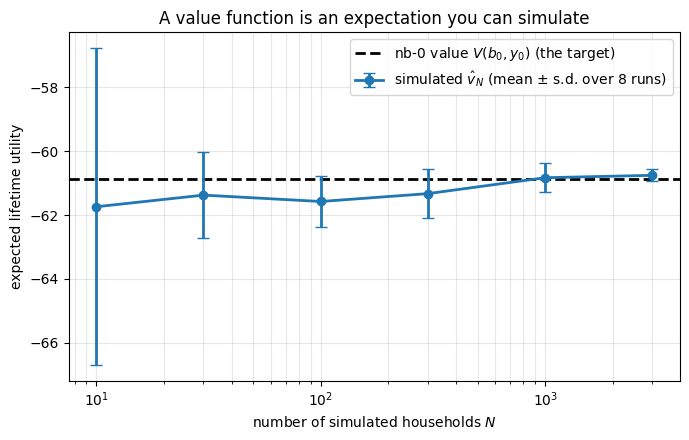

In [3]:
def u_flow(c):
    """Per-period utility, matching notebook 0 (so the estimate targets nb-0's V)."""
    c = np.maximum(c, eps)
    return np.log(c) if sigma == 1.0 else c ** (1 - sigma) / (1 - sigma)


b_grid_np, e_grid_np, Pi_np = np.asarray(b_grid), np.asarray(e_grid), np.asarray(Pi)
b0_idx, y0 = 10, 1                                   # start state (a grid point, so V is known)

def simulate_values(n_paths, T=400, seed=0):
    """Total discounted utility for n_paths households, all starting at (b0, y0)."""
    rng = np.random.default_rng(seed)
    b = np.full(n_paths, b_grid_np[b0_idx])
    y = np.full(n_paths, y0)
    total, discount = np.zeros(n_paths), 1.0
    for _ in range(T):
        c = np.empty(n_paths)                        # consume per the policy at each (b, y)
        for j in range(n_y):
            m = y == j
            c[m] = np.interp(b[m], b_grid_np, c_policy_np[:, j])
        total += discount * u_flow(c)
        discount *= beta
        b = (b + e_grid_np[y] - c) / q               # next assets from the budget constraint
        cdf = np.cumsum(Pi_np[y], axis=1)            # draw next income y' ~ Pi[y]
        y = (rng.random((n_paths, 1)) > cdf).sum(axis=1).clip(0, n_y - 1)
    return total


V_true = V_np[b0_idx, y0]
Ns = [10, 30, 100, 300, 1000, 3000]
reps = 8                                              # independent estimates per N, to show the spread
est = {N: np.array([simulate_values(N, seed=s).mean() for s in range(reps)]) for N in Ns}
means = [est[N].mean() for N in Ns]
stds = [est[N].std() for N in Ns]
print(f"nb-0 value V(b0,y0) = {V_true:.3f}")
for N, m, sd in zip(Ns, means, stds):
    print(f"  N={N:5d}:  v_hat = {m:8.3f} +/- {sd:.3f}   (error {m - V_true:+.3f})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(V_true, color="k", ls="--", lw=2, label="nb-0 value $V(b_0,y_0)$ (the target)")
ax.errorbar(Ns, means, yerr=stds, fmt="o-", lw=2, capsize=4,
            label=r"simulated $\hat v_N$ (mean $\pm$ s.d. over %d runs)" % reps)
ax.set_xscale("log")
ax.set_xlabel("number of simulated households $N$")
ax.set_ylabel("expected lifetime utility")
ax.set_title("A value function is an expectation you can simulate")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

The spread is wide for small $N$ and tightens around notebook 0's value as $N$
grows (the sampling error falls like $1/\sqrt{N}$). **That is the first
bridge:** we never need the Bellman equation to
*evaluate* a policy; simulation suffices. (This is also why the method scales
to hard problems: simulating forward stays cheap even when solving the Bellman
equation does not.)

## Bridge 2: structural knowledge makes the value *exactly* differentiable

Evaluating a policy is not enough; to *improve* it we need the gradient of the
value with respect to the policy parameters $\boldsymbol\theta$. This is where
SRL departs from textbook RL, by exploiting structure.

**Partition the dynamics into what we know and what we don't.** A household's
own dynamics are *known*: given a consumption policy, the budget constraint
$b' = (b + y - c)/q$ and the income process $\Pi$ pin down exactly where it
goes next. On the grid these known transitions assemble into one $J\times J$
**transition matrix $\mathbf{A}_\pi$** (the income transition $\Pi$ and the
linear-interpolation wealth transition baked in). It is *literally the same
histogram-transition operator* (Young, 2010) you used to move the distribution
forward in notebook 0. Because we *built* $\mathbf{A}_\pi$ from the model, we can
**differentiate through it exactly**.

With the individual dynamics carried by $\mathbf{A}_\pi$, the value becomes a
clean vector expression. Writing $\mathbf{u}_t = u(\mathbf{c}_t)$ for the vector
of flow utilities and $\mathbf{A}_{\pi,0\to t}=\mathbf{A}_{\pi,0}\cdots
\mathbf{A}_{\pi,t-1}$ for the $t$-step transition, the value *vector* is
$$\mathbf{v}_\pi=\mathbb{E}\Big[\textstyle\sum_{t\ge 0}\beta^t\,
  \mathbf{A}_{\pi,0\to t}\,\mathbf{u}_t\Big],$$
and (the structural point) **the expectation is taken only over what we do not
know**: the trajectories of prices $p_t$ and aggregate shocks $z_t$. The
individual transitions are never sampled; the matrix handles them exactly. In
*this* notebook the price is fixed and there is no aggregate shock, so there is
nothing left to sample: the value reduces to $\mathbf{v}_\pi=\sum_t\beta^t
\mathbf{A}_\pi^t\mathbf{u}=(\mathbf{I}-\beta\mathbf{A}_\pi)^{-1}\mathbf{u}$,
computed **exactly**, and so is its gradient.

**One normalization, used in every `step` below.** The flow utility is
multiplied by $(1-\beta)$. The reason: the discount weights $\beta^t$ sum to
$1/(1-\beta)$, so $(\mathbf{I}-\beta\mathbf{A}_\pi)^{-1}$ has row sums
$1/(1-\beta)$ and the raw value diverges as $\beta\to1$. Scaling $\mathbf{u}$ by
$(1-\beta)$ rewrites the value as a *convex combination* of flow utilities
(weights $(1-\beta)\beta^t$ that sum to $1$), a per-period-equivalent that stays
$O(1)$ for any discount factor, which keeps the objective and its gradient
well-scaled. It multiplies the objective by a positive constant, so the optimal
policy is unchanged.

> **Contrast with textbook RL.** REINFORCE and friends treat the environment as
> a black box they cannot differentiate, so they estimate the policy gradient
> from noisy sampled actions (high variance). SRL knows the individual dynamics
> and differentiates $\mathbf{A}_\pi$ directly: an *exact* gradient, no
> sampling noise. The presence of $\mathbf{A}_\pi$ in the objective is precisely
> what "Structural" refers to.

The `SPGSolver`'s objective is this value, written so JAX can differentiate it.
Read the `step` below: it pulls the transition $\mathbf{A}$ and utilities
$\mathbf{U}$ from the model, accumulates discounted utility weighted by a
distribution `d`, and pushes both `d` and the population `m` forward with
`apply_A_T` (i.e. $\mathbf{A}_\pi^{\rm T}$, the Chapman–Kolmogorov step from
nb 0). The two distributions play different roles (Bridge 3 explains `d`), and
the `stop_gradient` on the population `m` is **price-taking**: it matters in
general equilibrium (notebook 4), where prices feed back through the
distribution, and is inert here.

In [4]:
from srl import SPGSolver
print(inspect.getsource(SPGSolver._neg_simulated_utility))

    @partial(jax.jit, static_argnums=(0,))
    def _neg_simulated_utility(self, policy, key, m0):
        """Return (-mean discounted lifetime utility, final population dist).

        Averages over ``sample_size`` independent paths. Negated because the
        optimiser minimises.
        """
        def simulate_one_path(key, m0):
            def step(carry, _):
                m, d, s, discount, key = carry
                # The environment sees the population distribution, detached so the
                # gradient does not flow through the GE feedback channel.
                m_detached = jax.lax.stop_gradient(m)
                m_detached = m_detached / jnp.sum(m_detached, keepdims=True)
                key, subkey = jax.random.split(key)
                A, U, s = self.env_AUS_fn(policy, m_detached, s, subkey)
                # Flow contribution to the objective: utility weighted by the
                # differentiable distribution d, discounted to the present.
                fl

## Bridge 3: climb it

To optimize we need a *scalar* objective, not the whole value vector. The paper
averages the value over a uniform distribution $\mathbf{d}_0$ of starting states,
$$\mathcal{L}(\boldsymbol\theta)=\mathbf{d}_0^{\rm T}\,\hat{\mathbf{v}}_\pi
  =\sum_{t\ge 0}\beta^t\big\langle \mathbf{d}_t,\ \mathbf{u}_t\big\rangle,
  \qquad \mathbf{d}_{t+1}=\mathbf{A}_\pi^{\rm T}\mathbf{d}_t,\quad
  \mathbf{d}_0=\text{uniform}.$$
This is the same scalar but cheaper to form: rather than the big matrix products
$\mathbf{A}_{\pi,0\to t}$, just push the weight vector $\mathbf{d}_0$ forward by
$\mathbf{A}_\pi^{\rm T}$ each period (that is the `d` in the code above) and
accumulate $\beta^t\langle\mathbf{d}_t,\mathbf{u}_t\rangle$. Then climb:
$\boldsymbol\theta\leftarrow\boldsymbol\theta+\eta\,\nabla_{\boldsymbol\theta}
\mathcal{L}$. The solver uses Adam and gets $\nabla_{\boldsymbol\theta}\mathcal{L}$
from a single `jax.value_and_grad` on the objective above. The whole update is a
few lines:

In [5]:
print(inspect.getsource(SPGSolver._gradient_step))

    @partial(jax.jit, static_argnums=(0,))
    def _gradient_step(self, policy, opt_state, key, m0):
        """One Adam ascent step on the simulated-utility objective.

        Returns the updated policy, optimiser state, the (positive) objective
        value, and the final population distribution from the simulation.
        """
        (neg_utility, m_final), grads = jax.value_and_grad(
            self._neg_simulated_utility, has_aux=True
        )(policy, key, m0)
        updates, opt_state = self.optimizer.update(grads, opt_state)
        policy = optax.apply_updates(policy, updates)
        return policy, opt_state, -neg_utility, m_final



## Putting it together: the model as an environment

To use the solver we describe the model through two functions, the same
`(state_space, action_space, AUS_func, reset_func)` interface you met in
notebook 1's `VFISolver`, now driving the policy gradient:

- **`AUS_func`** returns, for the current policy, the transition triplets
  **A** (the sparse $\mathbf{A}_\pi$, in Young's histogram form), the utility
  vector **U** ($\mathbf{u}_t$), and the next exogenous state. This *is* the
  one-step economics: the same budget constraint and interpolation as nb 0.
- **`reset_func`** draws an initial exogenous state; here there is none (the
  price is a fixed scalar and there is no aggregate shock), so it returns
  `None`.

The action is the consumption share `cshare`$(b,y)$. Everything below is the
household model you already know, expressed as code the solver can simulate and
differentiate.

In [6]:
from srl.utils.safe_linalg import crra_util_func, interp_two_point_nonuniform


def reset_func(key):
    return None                                       # no exogenous state in this model


def AUS_func(policy, mt, st, key):
    """One-step economics: (policy, distribution, state, key) -> (A, U, next state)."""
    J = n_b * n_y                                     # joint (b, y) states

    def build_row(idx):
        b_idx, y_idx = idx // n_y, idx % n_y
        b, y = b_grid[b_idx], e_grid[y_idx]
        cshare = policy["cshare"][b_idx, y_idx]
        wealth = b + y
        c = jnp.clip(wealth * cshare, eps, wealth - eps)
        utility = crra_util_func(c, sigma) * (1.0 - gamma)   # (1-gamma): normalized value
        b_next = (wealth - c) / q
        # Place b' on the grid by linear interpolation -> the A_pi transition row.
        lo, hi, w_lo, w_hi = interp_two_point_nonuniform(b_next, b_grid)
        cols = jnp.concatenate([lo * n_y + jnp.arange(n_y, dtype=jnp.int32),
                                hi * n_y + jnp.arange(n_y, dtype=jnp.int32)])
        rows = jnp.full((2 * n_y,), idx, dtype=jnp.int32)
        vals = jnp.concatenate([w_lo * Pi[y_idx], w_hi * Pi[y_idx]])  # x income transition
        return (rows, cols, vals), utility

    A, U = jax.vmap(build_row)(jnp.arange(J, dtype=jnp.int32))
    return A, U, None


state_space = {"b": ("markov", n_b), "y": ("markov", n_y)}
action_space = {"cshare": (0.0001, 1.0, 0.5)}         # (min, max, initial guess = 0.5)
gamma = beta                                          # the solver's discount argument

Now train. We use paper-scale settings: a large sample size and many epochs
sharpen the policy, especially in rarely-visited states. This is solved on GPU.

In [7]:
%%time 

solver = SPGSolver(sample_size=16, epoch=400, warm_up=0, early_stop=False,
                   seed=0, verbose=False)
spg_policy, logs = solver.solve(gamma, state_space, action_space, AUS_func, reset_func)
print(f"SPG: {len(logs)} epochs, {solver.total_time:.1f}s")

wealth = b_grid[:, None] + e_grid[None, :]
c_spg = np.clip(np.asarray(wealth) * np.asarray(spg_policy["cshare"]), eps,
                np.asarray(wealth) - eps)

100%|██████████| 400/400 [00:07<00:00, 54.49it/s, max_l1_err=7.213E-05, time(sec)=7.180, cum(EU)=-0.0986]


SPG: 400 epochs, 7.2s
CPU times: user 7.15 s, sys: 744 ms, total: 7.89 s
Wall time: 8.02 s


### Watch the objective climb, and the policy with it

Gradient ascent raises expected lifetime utility each step (left). The policy
starts at a flat guess (consume half of cash-on-hand everywhere, the straight
line $c = 0.5\,(b+y)$) and bends toward notebook 0's VFI policy as it climbs
(right).

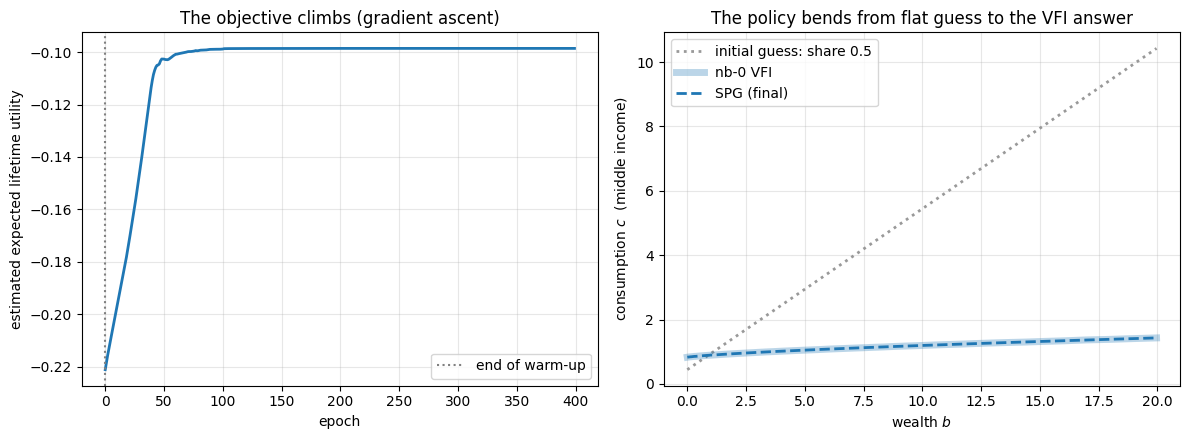

In [8]:
init_c = np.asarray(wealth) * 0.5                      # the initial flat guess, as consumption
b_np = b_grid_np
mask = b_np <= 20
j = 1                                                  # middle income state, for the policy panel

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
axL.plot([d["cumulative_utility"] for d in logs], lw=2)
axL.axvline(solver.warm_up, color="gray", ls=":", lw=1.5, label="end of warm-up")
axL.set_xlabel("epoch")
axL.set_ylabel("estimated expected lifetime utility")
axL.set_title("The objective climbs (gradient ascent)")
axL.legend()
axL.grid(alpha=0.3)

axR.plot(b_np[mask], init_c[mask, j], color="0.6", lw=2, ls=":", label="initial guess: share 0.5")
axR.plot(b_np[mask], c_policy_np[mask, j], lw=5, alpha=0.3, color="C0", label="nb-0 VFI")
axR.plot(b_np[mask], c_spg[mask, j], lw=2, ls="--", color="C0", label="SPG (final)")
axR.set_xlabel("wealth $b$")
axR.set_ylabel("consumption $c$  (middle income)")
axR.set_title("The policy bends from flat guess to the VFI answer")
axR.legend()
axR.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The check: does the policy gradient land on notebook 0's answer?

The whole point: a completely different method must recover the same
consumption policy. We overlay the SPG policy (dashed) on the notebook-0 VFI
baseline (solid) for all three income states.

over the plotted region (b <= 20):  max |c_SPG - c_VFI| = 6.237e-03, mean = 6.335e-04


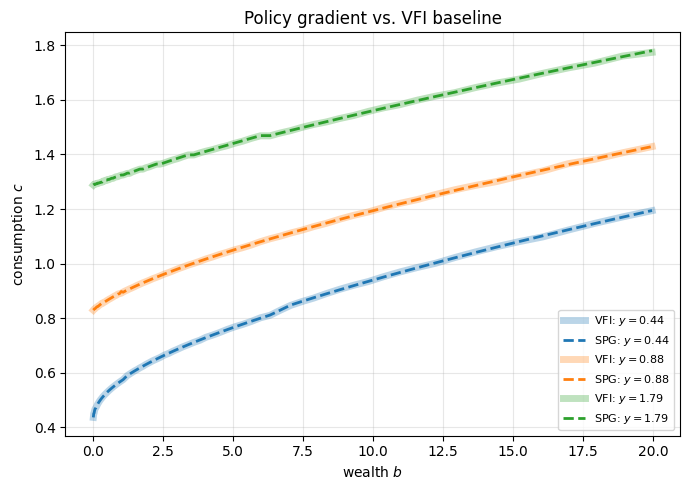

In [9]:
max_plot = float(np.max(np.abs(c_spg[mask] - c_policy_np[mask])))
mean_plot = float(np.mean(np.abs(c_spg[mask] - c_policy_np[mask])))
print(f"over the plotted region (b <= 20):  max |c_SPG - c_VFI| = {max_plot:.3e}, "
      f"mean = {mean_plot:.3e}")

fig, ax = plt.subplots(figsize=(7, 5))
for jj in range(n_y):
    line, = ax.plot(b_np[mask], c_policy_np[mask, jj], lw=5, alpha=0.3,
                    label=f"VFI: $y={float(e_grid[jj]):.2f}$")
    ax.plot(b_np[mask], c_spg[mask, jj], lw=2, ls="--", color=line.get_color(),
            label=f"SPG: $y={float(e_grid[jj]):.2f}$")
ax.set_xlabel("wealth $b$")
ax.set_ylabel("consumption $c$")
ax.set_title("Policy gradient vs. VFI baseline")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

One final comment: SPG learns *only
where households actually go*. The stationary distribution puts almost no mass
at very high wealth, so the gradient signal there is tiny and SPG leaves those
states near their initial guess, whereas VFI solves every grid point equally
well, visited or not. Restricting the comparison to the populated region
(`b <= 20`) is the honest comparison; it is also a preview of the method's
character: it spends its effort where the economy lives.

## What's next

We have now solved one fixed-price household problem three ways: VFI in NumPy
(nb 0), VFI in JAX (nb 1), and the structural policy gradient (nb 2). All
three agree. With the method established and trusted, **notebook 3** switches on
an *exogenous price process* $p_t$: the expectation over prices in
$\mathbf{v}_\pi$ stops being trivial, and the household begins to condition on
prices that move, the rehearsal for how SRL handles general equilibrium.

## Exercises

1. **Convergence vs. gradient variance.** The estimate $\hat v$ is averaged
   over `sample_size` simulated paths; fewer paths "usually" means a noisier gradient.
   But this is not always true!
   Re-train with `sample_size = 1` and `sample_size = 256` and compare the
   objective curves. A worked version is
   below.
2. **Start from a bad policy.** Initialize the consumption share at $0.95$
   everywhere (a household that consumes almost everything) and confirm gradient
   ascent still converges to the same policy. Worked below.

100%|██████████| 400/400 [00:07<00:00, 56.31it/s, max_l1_err=6.498E-05, time(sec)=6.815, cum(EU)=-0.0986]


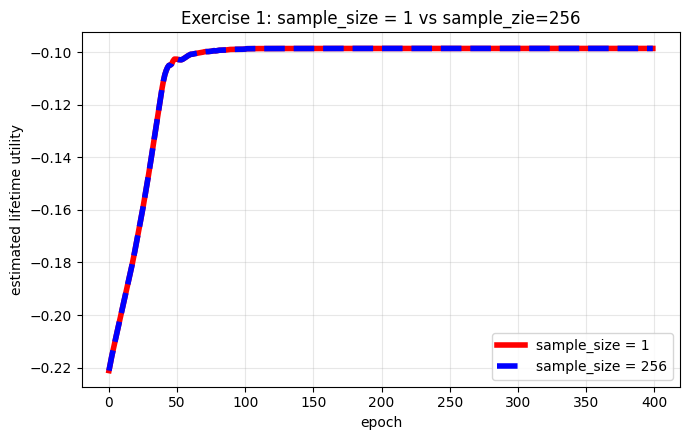

In [10]:
# Exercise 1: sample size vs. gradient noise (short runs to keep it quick).
fig, ax = plt.subplots(figsize=(7, 4.5))
for ss in [1, 256]:
    s = SPGSolver(sample_size=ss, epoch=400, warm_up=0, early_stop=False,
                  seed=0, verbose=False)
    _, lg = s.solve(gamma, state_space, action_space, AUS_func, reset_func)
    line,color = ("-","red") if ss == 1 else ("--", "blue")
    ax.plot([d["cumulative_utility"] for d in lg], lw=4, label=f"sample_size = {ss}", linestyle=line,color=color)
ax.set_xlabel("epoch")
ax.set_ylabel("estimated lifetime utility")
ax.set_title("Exercise 1: sample_size = 1 vs sample_zie=256")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:13<00:00, 74.18it/s, max_l1_err=1.424E-03, time(sec)=12.789, cum(EU)=-0.0986]


from s=0.95 start:  max |c - c_VFI| over b<=20 = 6.230e-03


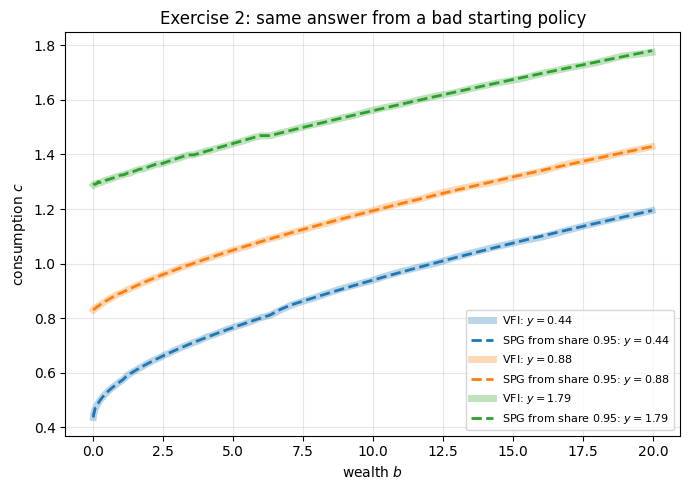

In [11]:
# Exercise 2: converge from a deliberately bad initial policy (s = 0.95).
bad_init = {"cshare": jnp.ones((n_b, n_y)) * 0.95}
s = SPGSolver(sample_size=1, epoch=1000, warm_up=0, early_stop=False,
              seed=0, verbose=False, lr_decay=1.0)
bad_policy, _ = s.solve(gamma, state_space, action_space, AUS_func, reset_func,
                        policy=bad_init)
c_bad = np.clip(np.asarray(wealth) * np.asarray(bad_policy["cshare"]), eps,
                np.asarray(wealth) - eps)
print(f"from s=0.95 start:  max |c - c_VFI| over b<=20 = "
      f"{np.max(np.abs(c_bad[mask] - c_policy_np[mask])):.3e}")

fig, ax = plt.subplots(figsize=(7, 5))
for jj in range(n_y):
    line, = ax.plot(b_np[mask], c_policy_np[mask, jj], lw=5, alpha=0.3,
                    label=f"VFI: $y={float(e_grid[jj]):.2f}$")
    ax.plot(b_np[mask], c_bad[mask, jj], lw=2, ls="--", color=line.get_color(),
            label=f"SPG from share 0.95: $y={float(e_grid[jj]):.2f}$")
ax.set_xlabel("wealth $b$")
ax.set_ylabel("consumption $c$")
ax.set_title("Exercise 2: same answer from a bad starting policy")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()